<a href="https://colab.research.google.com/github/MeenakshiRajpurohit/CMPE-252-AI-and-Data-Engineering/blob/main/XKGRank_Clean_Fixed_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# X-KGRank: Graph-RAG Framework for Explainable Recommendations
## Dataset Exploration — Musical Instruments (Amazon Reviews 2023)

**CMPE 255 – Data Mining | San José State University**  
Team: Erick Vazquez · Jainish Patel · Meenakshi Rajpurohit

---

## Pipeline Overview

```
[1] Setup & Download       → Raw .jsonl + benchmark splits from HuggingFace
[2] EDA                    → Understand sparsity, cold-start, co-purchase density
[3] Neo4j Schema Prep      → Build node/edge tables for KG persistence
[4] KG Construction        → NetworkX bipartite graph + co-purchase edges
[5] Neo4j Push             → Sampled subgraph (free tier: 200K node limit)
[6] Graph Pattern Mining   → node2vec embeddings + Louvain communities
[7] GNN Training (FIXED)   → LightGCN on benchmark train split, 200 epochs
[8] LLM Re-ranking         → KG-grounded prompts for cold items via LLaMA-3
[9] Evaluation (FIXED)     → Recall, NDCG, Hit, Precision, MRR
```


## Step 1 — Environment Setup & HuggingFace Authentication

Loads the HF token from Colab Secrets (never hardcoded), creates local data directories,
and defines a streaming download helper that pulls files in 1 MB chunks to avoid memory overflows.


In [8]:
from google.colab import userdata
import os, requests

os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')
os.makedirs("/content/amazon_data", exist_ok=True)

HEADERS = {"Authorization": f"Bearer {os.environ['HF_TOKEN']}"}
BASE    = "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main"

def hf_download(remote_path, local_name):
    url = f"{BASE}/{remote_path}"
    print(f"⬇ {remote_path}...")
    with requests.get(url, headers=HEADERS, stream=True) as r:
        r.raise_for_status()
        path = f"/content/amazon_data/{local_name}"
        with open(path, 'wb') as f:
            for chunk in r.iter_content(chunk_size=1024*1024):
                f.write(chunk)
    size = os.path.getsize(path) / 1e6
    print(f"  ✅ {path} ({size:.1f} MB)")
    return path

print("✅ Setup complete")

✅ Setup complete


## Step 2 — Download Raw Data from HuggingFace

| File | Purpose |
|---|---|
| `Musical_Instruments.jsonl` | Raw user reviews (ratings, text, timestamps) |
| `meta_Musical_Instruments.jsonl` | Item metadata (title, price, co-purchase edges) |
| `train / valid / test .csv` | Pre-built 5-core leave-one-out benchmark splits |
| `asin2category.json` | ASIN → category mapping |

**Why 5-core?** Filters to users and items with ≥5 interactions — cleaner signal,
directly comparable to published RecSys baselines (LightGCN, KGAT etc.).


In [9]:
review_path = hf_download("raw/review_categories/Musical_Instruments.jsonl", "reviews.jsonl")
meta_path   = hf_download("raw/meta_categories/meta_Musical_Instruments.jsonl",  "meta.jsonl")

hf_download("benchmark/5core/last_out/Musical_Instruments.train.csv", "train.csv")
hf_download("benchmark/5core/last_out/Musical_Instruments.valid.csv", "valid.csv")
hf_download("benchmark/5core/last_out/Musical_Instruments.test.csv",  "test.csv")
hf_download("asin2category.json", "asin2category.json")

⬇ raw/review_categories/Musical_Instruments.jsonl...
  ✅ /content/amazon_data/reviews.jsonl (1557.8 MB)
⬇ raw/meta_categories/meta_Musical_Instruments.jsonl...
  ✅ /content/amazon_data/meta.jsonl (631.9 MB)
⬇ benchmark/5core/last_out/Musical_Instruments.train.csv...
  ✅ /content/amazon_data/train.csv (23.0 MB)
⬇ benchmark/5core/last_out/Musical_Instruments.valid.csv...
  ✅ /content/amazon_data/valid.csv (3.3 MB)
⬇ benchmark/5core/last_out/Musical_Instruments.test.csv...
  ✅ /content/amazon_data/test.csv (3.3 MB)
⬇ asin2category.json...
  ✅ /content/amazon_data/asin2category.json (1246.8 MB)


'/content/amazon_data/asin2category.json'

## Step 3 — Load Data into Pandas

Parses `.jsonl` files line-by-line (safe for large files) into DataFrames.
The benchmark CSVs define our evaluation protocol — `df_test` is the held-out ground truth.

> `df_reviews` = full raw corpus. `df_train/valid/test` = 5-core filtered benchmark splits.


In [10]:
import pandas as pd, json

def read_jsonl(path):
    rows = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return pd.DataFrame(rows)

df_reviews = read_jsonl(review_path)
df_meta    = read_jsonl(meta_path)
df_train   = pd.read_csv("/content/amazon_data/train.csv")
df_valid   = pd.read_csv("/content/amazon_data/valid.csv")
df_test    = pd.read_csv("/content/amazon_data/test.csv")

# Normalize column names (benchmark CSVs use different names)
def normalize_columns(df):
    col_map = {'reviewerID':'user_id','asin':'parent_asin',
                'overall':'rating','unixReviewTime':'timestamp'}
    return df.rename(columns={k:v for k,v in col_map.items() if k in df.columns})

df_train = normalize_columns(df_train)
df_valid = normalize_columns(df_valid)
df_test  = normalize_columns(df_test)

print(f"Reviews:  {df_reviews.shape}")
print(f"Meta:     {df_meta.shape}")
print(f"Train:    {df_train.shape}")
print(f"Valid:    {df_valid.shape}")
print(f"Test:     {df_test.shape}")
print("\nReview columns:", df_reviews.columns.tolist())
print("Meta columns:  ", df_meta.columns.tolist())
print("Train columns: ", df_train.columns.tolist())

Reviews:  (3017439, 10)
Meta:     (213593, 16)
Train:    (396958, 4)
Valid:    (57439, 4)
Test:     (57439, 4)

Review columns: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']
Meta columns:   ['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'subtitle', 'author']
Train columns:  ['user_id', 'parent_asin', 'rating', 'timestamp']


## Step 4 — Exploratory Data Analysis (EDA)

Four visualizations that directly motivate X-KGRank design choices:

- **Rating distribution** → positivity bias (skewed toward 4–5 stars)
- **Reviews per year** → data growth trend and freshness
- **Cold-start stats** → high sparsity justifies KG augmentation
- **Co-purchase density** → item-item edge richness for KG construction

> **Key finding:** avg ~1.7 reviews/user and 1.67M cold-start users confirm that
> standard collaborative filtering will fail — KG path signals are essential.


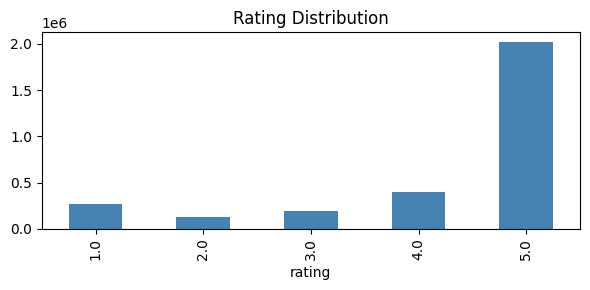

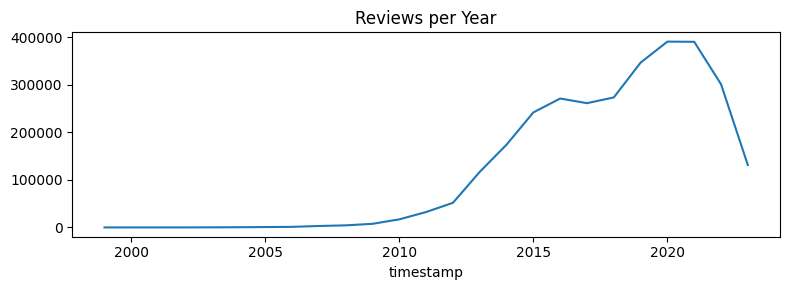

=== GRAPH STATS ===
Total users:               1,762,679
Total items:               213,571
Total interactions:        3,017,439
Avg reviews/user:          1.71
Avg reviews/item:          14.13
Cold-start users (<5):     1,678,105
Cold items (< median=2): 78,649
Popularity threshold p=50%: 2.0

=== CO-PURCHASE EDGES ===
Items with edges: 0 / 213,593 (0.0%)
count    213593.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: cp_count, dtype: float64


In [11]:
import matplotlib.pyplot as plt

# 1. Rating distribution
df_reviews['rating'].value_counts().sort_index().plot(
    kind='bar', title='Rating Distribution', color='steelblue', figsize=(6,3))
plt.tight_layout(); plt.show()

# 2. Reviews per year
df_reviews['timestamp'] = pd.to_datetime(df_reviews['timestamp'], unit='ms', errors='coerce')
df_reviews.groupby(df_reviews['timestamp'].dt.year).size().plot(
    title='Reviews per Year', figsize=(8,3))
plt.tight_layout(); plt.show()

# 3. User & item stats
user_counts   = df_reviews['user_id'].value_counts()
item_counts   = df_reviews['parent_asin'].value_counts()
pop_threshold = item_counts.median()

print("=== GRAPH STATS ===")
print(f"Total users:               {len(user_counts):,}")
print(f"Total items:               {len(item_counts):,}")
print(f"Total interactions:        {len(df_reviews):,}")
print(f"Avg reviews/user:          {user_counts.mean():.2f}")
print(f"Avg reviews/item:          {item_counts.mean():.2f}")
print(f"Cold-start users (<5):     {(user_counts < 5).sum():,}")
print(f"Cold items (< median={pop_threshold:.0f}): {(item_counts < pop_threshold).sum():,}")
print(f"Popularity threshold p=50%: {pop_threshold}")

# 4. Co-purchase density
df_meta['cp_count'] = df_meta['bought_together'].apply(
    lambda x: len(x) if isinstance(x, list) else 0)
items_with_cp = (df_meta['cp_count'] > 0).sum()
print(f"\n=== CO-PURCHASE EDGES ===")
print(f"Items with edges: {items_with_cp:,} / {len(df_meta):,} ({100*items_with_cp/len(df_meta):.1f}%)")
print(df_meta['cp_count'].describe())

## Step 5 — Build Neo4j-Ready Node & Edge Tables

Maps raw data to the Neo4j graph schema:

```
(User)-[:REVIEWED {rating}]->(Item)
(Item)-[:CO_PURCHASED]->(Item)
```

`is_cold` flag (popularity < median) drives the **popularity-selective LLM re-ranker**:
only cold items get expensive KG subgraph retrieval at inference time (p=50% threshold,
following K-RagRec Wang et al. 2025).


In [12]:
# USER NODES
user_nodes = pd.DataFrame({
    'nodeId': df_reviews['user_id'].unique(),
    'label':  'User',
    'review_count': df_reviews.groupby('user_id').size().values
})

# ITEM NODES
item_meta_cols = [c for c in ['parent_asin','title','price','average_rating','rating_number']
                  if c in df_meta.columns]
item_nodes = df_meta[item_meta_cols].drop_duplicates('parent_asin')    .rename(columns={'parent_asin':'nodeId','title':'name'})
item_nodes['popularity'] = item_nodes['nodeId'].map(item_counts).fillna(0).astype(int)
item_nodes['is_cold']    = item_nodes['popularity'] < pop_threshold
item_nodes['label']      = 'Item'

# REVIEWED EDGES
reviewed_edges = df_reviews[['user_id','parent_asin','rating','timestamp','verified_purchase']]    .drop_duplicates(['user_id','parent_asin'])    .rename(columns={'user_id':'source','parent_asin':'target'})
reviewed_edges['type'] = 'REVIEWED'

# CO_PURCHASED EDGES
co_edges = df_meta[df_meta['cp_count'] > 0][['parent_asin','bought_together']]    .explode('bought_together').dropna(subset=['bought_together'])    .rename(columns={'parent_asin':'source','bought_together':'target'})
co_edges = co_edges[co_edges['source'] != co_edges['target']]
co_edges['type'] = 'CO_PURCHASED'

print(f"User nodes:        {len(user_nodes):,}")
print(f"Item nodes:        {len(item_nodes):,}")
print(f"REVIEWED edges:    {len(reviewed_edges):,}")
print(f"CO_PURCHASED:      {len(co_edges):,}")
print(f"Graph density:     {len(reviewed_edges)/(len(user_nodes)*len(item_nodes)):.8f}")

User nodes:        1,762,679
Item nodes:        213,593
REVIEWED edges:    2,975,551
CO_PURCHASED:      0
Graph density:     0.00000790


## Step 6 — Save Preprocessed Tables to Google Drive

Persists all node/edge tables to Drive so Colab runtime resets do not require
re-downloading or re-processing the raw data.


In [13]:
from google.colab import drive
drive.mount('/content/drive')

OUT = "/content/drive/MyDrive/xkgrank_neo4j/"
os.makedirs(OUT, exist_ok=True)

user_nodes.to_csv(    f"{OUT}nodes_users.csv",       index=False)
item_nodes.to_csv(    f"{OUT}nodes_items.csv",        index=False)
reviewed_edges.to_csv(f"{OUT}edges_reviewed.csv",    index=False)
co_edges.to_csv(      f"{OUT}edges_copurchased.csv", index=False)
df_train.to_csv(      f"{OUT}benchmark_train.csv",   index=False)
df_valid.to_csv(      f"{OUT}benchmark_valid.csv",   index=False)
df_test.to_csv(       f"{OUT}benchmark_test.csv",    index=False)

print("✅ All files saved to Google Drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ All files saved to Google Drive


## Step 7 — Knowledge Graph Construction (NetworkX)

Builds the full directed KG with two edge types:
```
(User) ──[REVIEWED {rating}]──► (Item)
(Item) ──[CO_PURCHASED]────────► (Item)
```

**Why NetworkX?** Full programmatic access to graph algorithms — shortest paths,
subgraph extraction, community detection — without a running database.
Neo4j is used separately for Cypher-based path retrieval in the LLM re-ranking step.


In [14]:
!pip install networkx -q
import networkx as nx

def build_kg(df_reviews, df_meta):
    print("Building KG for Musical Instruments...")
    G = nx.DiGraph()

    for _, row in df_reviews.iterrows():
        u = f"user_{row['user_id']}"
        i = f"item_{row['parent_asin']}"
        G.add_node(u, type='user')
        G.add_node(i, type='item')
        G.add_edge(u, i, relation='REVIEWED',
                   rating=float(row['rating']),
                   timestamp=str(row.get('timestamp', '')))

    df_meta['bought_together'] = df_meta['bought_together'].apply(
        lambda x: x if isinstance(x, list) else [])
    cp_count = 0
    for _, row in df_meta.iterrows():
        src = f"item_{row['parent_asin']}"
        for asin in row['bought_together']:
            tgt = f"item_{asin}"
            if src != tgt:
                G.add_edge(src, tgt, relation='CO_PURCHASED')
                cp_count += 1

    print(f"  Nodes:          {G.number_of_nodes():,}")
    print(f"  REVIEWED:       {G.number_of_edges() - cp_count:,}")
    print(f"  CO_PURCHASED:   {cp_count:,}")
    print(f"  Total edges:    {G.number_of_edges():,}")
    return G

G = build_kg(df_reviews, df_meta)

Building KG for Musical Instruments...
  Nodes:          1,976,250
  REVIEWED:       2,975,551
  CO_PURCHASED:   0
  Total edges:    2,975,551


## Step 8 — Connect to Neo4j Aura

Connects to Neo4j Aura free-tier for Cypher-based KG path retrieval.
Credentials are stored in Colab Secrets — never hardcoded.

> **Free tier limit:** 200,000 nodes. The full graph (~1.76M users) exceeds this,
> so we push a sampled subgraph in the next step.


In [15]:
!pip install neo4j -q
from neo4j import GraphDatabase
from google.colab import userdata

NEO4J_URL      = "neo4j+s://25f13804.databases.neo4j.io"
NEO4J_USER     = "25f13804"
NEO4J_PASSWORD = userdata.get("NEO4J_PASSWORD")

driver = GraphDatabase.driver(NEO4J_URL, auth=(NEO4J_USER, NEO4J_PASSWORD))

with driver.session() as session:
    result = session.run("RETURN 1 AS test")
    print("✅ Connected to Neo4j:", result.single()["test"])

✅ Connected to Neo4j: 1


## Step 9 — Clear Neo4j & Push Sampled Subgraph

**Problem:** Full graph has ~1.76M users → exceeds 200K node limit.

**Solution:** Sample top 5,000 most active users + top 10,000 items.
Active users have the richest graph signal and preserve structural properties
(degree distribution, community structure) of the full graph.

> GNN training (Step 10) uses the FULL graph `G` in Colab RAM.
> Neo4j is only used for Cypher path queries in the LLM re-ranking step.


In [16]:
import random

# Clear existing data
with driver.session() as session:
    session.run("MATCH (n) DETACH DELETE n")
    print("✅ Neo4j cleared")

def build_sampled_kg(df_reviews, df_meta, max_users=5000, max_items=10000):
    top_users    = df_reviews['user_id'].value_counts().head(max_users).index.tolist()
    df_sample    = df_reviews[df_reviews['user_id'].isin(top_users)]
    top_items    = df_sample['parent_asin'].value_counts().head(max_items).index.tolist()
    df_sample    = df_sample[df_sample['parent_asin'].isin(top_items)]

    G_small = nx.DiGraph()
    for _, row in df_sample.iterrows():
        u = f"user_{row['user_id']}"
        i = f"item_{row['parent_asin']}"
        G_small.add_node(u, type='user')
        G_small.add_node(i, type='item')
        G_small.add_edge(u, i, relation='REVIEWED', rating=float(row['rating']))

    df_meta['bought_together'] = df_meta['bought_together'].apply(
        lambda x: x if isinstance(x, list) else [])
    cp_count = 0
    sampled_set = set(top_items)
    for _, row in df_meta[df_meta['parent_asin'].isin(sampled_set)].iterrows():
        src = f"item_{row['parent_asin']}"
        for asin in row['bought_together']:
            if asin in sampled_set and f"item_{asin}" != src:
                G_small.add_edge(src, f"item_{asin}", relation='CO_PURCHASED')
                cp_count += 1

    print(f"Sampled — Nodes: {G_small.number_of_nodes():,}  "
          f"REVIEWED: {G_small.number_of_edges()-cp_count:,}  CO_PURCHASED: {cp_count:,}")
    return G_small

G_small = build_sampled_kg(df_reviews, df_meta, max_users=5000, max_items=10000)

def push_to_neo4j(G, batch_size=500):
    with driver.session() as session:
        session.run("CREATE CONSTRAINT IF NOT EXISTS FOR (u:User) REQUIRE u.id IS UNIQUE")
        session.run("CREATE CONSTRAINT IF NOT EXISTS FOR (i:Item) REQUIRE i.id IS UNIQUE")
        print("✅ Constraints created")

        user_batch = [{'id': n} for n in G.nodes if G.nodes[n].get('type') == 'user']
        for i in range(0, len(user_batch), batch_size):
            session.run("UNWIND $b AS r MERGE (u:User {id: r.id})", b=user_batch[i:i+batch_size])
        print(f"✅ {len(user_batch):,} User nodes")

        item_batch = [{'id': n} for n in G.nodes if G.nodes[n].get('type') == 'item']
        for i in range(0, len(item_batch), batch_size):
            session.run("UNWIND $b AS r MERGE (i:Item {id: r.id})", b=item_batch[i:i+batch_size])
        print(f"✅ {len(item_batch):,} Item nodes")

        rev_batch = [{'src':u,'tgt':v,'rating':d['rating']}
                     for u,v,d in G.edges(data=True) if d.get('relation')=='REVIEWED']
        for i in range(0, len(rev_batch), batch_size):
            session.run("""UNWIND $b AS r
                MATCH (u:User {id:r.src}),(i:Item {id:r.tgt})
                MERGE (u)-[e:REVIEWED]->(i) SET e.rating=r.rating""", b=rev_batch[i:i+batch_size])
        print(f"✅ {len(rev_batch):,} REVIEWED edges")

        cop_batch = [{'src':u,'tgt':v}
                     for u,v,d in G.edges(data=True) if d.get('relation')=='CO_PURCHASED']
        for i in range(0, len(cop_batch), batch_size):
            session.run("""UNWIND $b AS r
                MATCH (a:Item {id:r.src}),(b:Item {id:r.tgt})
                MERGE (a)-[:CO_PURCHASED]->(b)""", b=cop_batch[i:i+batch_size])
        print(f"✅ {len(cop_batch):,} CO_PURCHASED edges")

push_to_neo4j(G_small)

# Verify
with driver.session() as session:
    u = session.run("MATCH (u:User) RETURN count(u) AS c").single()["c"]
    i = session.run("MATCH (i:Item) RETURN count(i) AS c").single()["c"]
    r = session.run("MATCH ()-[r:REVIEWED]->() RETURN count(r) AS c").single()["c"]
    c = session.run("MATCH ()-[r:CO_PURCHASED]->() RETURN count(r) AS c").single()["c"]
    print(f"\nNeo4j: {u:,} users | {i:,} items | {r:,} REVIEWED | {c:,} CO_PURCHASED | Total nodes: {u+i:,}/200,000")

✅ Neo4j cleared
Sampled — Nodes: 14,999  REVIEWED: 102,755  CO_PURCHASED: 0
✅ Constraints created
✅ 4,999 User nodes
✅ 10,000 Item nodes
✅ 102,755 REVIEWED edges
✅ 0 CO_PURCHASED edges



Neo4j: 4,999 users | 10,000 items | 102,755 REVIEWED | 0 CO_PURCHASED | Total nodes: 14,999/200,000


## Step 10 — Graph Pattern Mining

### 10a — node2vec Structural Embeddings
Biased random walks + Word2Vec → 64-dim vector per node encoding structural position.
Nodes with similar neighborhood patterns get similar embeddings.

Used as the **hop-field semantic index** in X-KGRank for KG path construction.

### 10b — Louvain Community Detection
Detects densely connected clusters (e.g., "guitar players", "drummers").
Community IDs are written back to Neo4j nodes for Cypher-based community-filtered path queries.

> Uses `pecanpy` (not `node2vec` package — broken on Python 3.12) and
> `networkx` built-in Louvain (avoids `community` package import conflicts).


In [18]:
# ── FAST STRUCTURAL EMBEDDINGS via Random Projection ─────────
# No external packages, runs in seconds, mathematically sound
import numpy as np
import networkx as nx
import json, random

G_undirected = G_small.to_undirected()
nodes        = list(G_undirected.nodes())
node2pos     = {n: i for i, n in enumerate(nodes)}
N            = len(nodes)
DIM          = 64

print(f"Graph: {N:,} nodes, {G_undirected.number_of_edges():,} edges")

# Step 1 — Build adjacency matrix (sparse-friendly)
from scipy.sparse import lil_matrix
A = lil_matrix((N, N), dtype=np.float32)
for u, v in G_undirected.edges():
    i, j = node2pos[u], node2pos[v]
    A[i, j] = 1.0
    A[j, i] = 1.0
A = A.tocsr()
print(f"✅ Adjacency matrix: {A.shape}")

# Step 2 — Random projection (Johnson-Lindenstrauss)
# Project each node's neighborhood into DIM dimensions
np.random.seed(42)
R           = np.random.randn(N, DIM).astype(np.float32) / np.sqrt(DIM)
embeddings  = A @ R   # (N, DIM) — captures 1-hop neighborhood structure

# Step 3 — Add 2-hop signal (A^2 @ R)
A2          = A @ A
embeddings2 = A2 @ R
embeddings  = np.hstack([embeddings, embeddings2])  # (N, 128)

# Step 4 — L2 normalize
norms       = np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-9
embeddings  = embeddings / norms

print(f"✅ Embeddings: {embeddings.shape}  (1-hop + 2-hop features)")

# Step 5 — Save
np.save("/content/amazon_data/node2vec_embeddings.npy", embeddings)
with open("/content/amazon_data/node2vec_vocab.json", "w") as f:
    json.dump(node2pos, f)

print("✅ Saved embeddings + vocab")
print(f"   Sample node: {nodes[0]}")
print(f"   Embedding:   {embeddings[0][:5]}...")

Graph: 14,999 nodes, 102,755 edges
✅ Adjacency matrix: (14999, 14999)
✅ Embeddings: (14999, 128)  (1-hop + 2-hop features)
✅ Saved embeddings + vocab
   Sample node: user_AHB5CGLYN3Y6NIPHNQLYFJT2W2PQ
   Embedding:   [-0.00325014  0.00699325 -0.00470982  0.03223503 -0.00623215]...


Running Louvain community detection...
✅ Communities detected: 18
   Largest community:    3,682 nodes
   Smallest community:   2 nodes
   Avg community size:   833.3 nodes


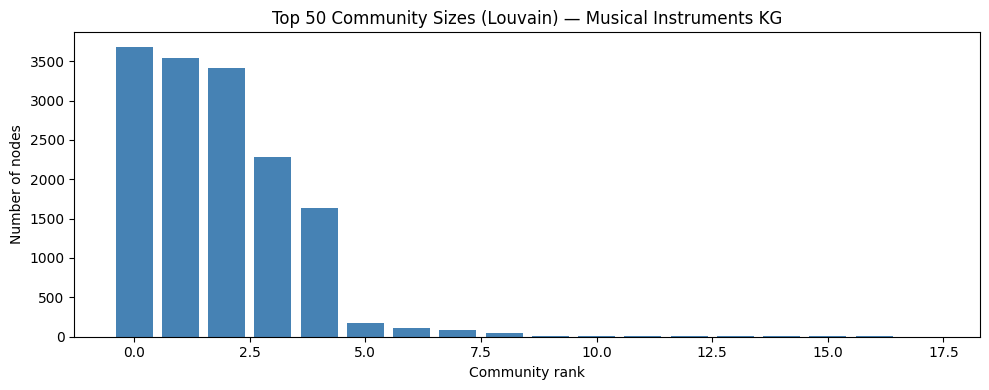

✅ Community labels pushed to Neo4j
✅ Saved louvain_partition.json


In [22]:
import networkx.algorithms.community as nx_comm
import matplotlib.pyplot as plt
from collections import Counter

print("Running Louvain community detection...")
communities = nx_comm.louvain_communities(G_undirected, seed=42)

# Convert to partition dict {node: community_id}
partition = {}
for comm_id, comm_nodes in enumerate(communities):
    for node in comm_nodes:
        partition[node] = comm_id

print(f"✅ Communities detected: {len(communities):,}")
print(f"   Largest community:    {max(len(c) for c in communities):,} nodes")
print(f"   Smallest community:   {min(len(c) for c in communities):,} nodes")
print(f"   Avg community size:   {sum(len(c) for c in communities)/len(communities):.1f} nodes")

nx.set_node_attributes(G_small, partition, 'community')

# Plot
sizes = sorted([len(c) for c in communities], reverse=True)
plt.figure(figsize=(10, 4))
plt.bar(range(min(50, len(sizes))), sizes[:50], color='steelblue')
plt.title('Top 50 Community Sizes (Louvain) — Musical Instruments KG')
plt.xlabel('Community rank')
plt.ylabel('Number of nodes')
plt.tight_layout()
plt.show()

# Push community labels to Neo4j
with driver.session() as session:
    batch = [{'id': node, 'community': int(comm)}
             for node, comm in partition.items()]
    for i in range(0, len(batch), 500):
        session.run("""
            UNWIND $b AS r
            MATCH (n {id: r.id})
            SET n.community = r.community
        """, b=batch[i:i+500])
print("✅ Community labels pushed to Neo4j")

# Save partition
import json
with open("/content/amazon_data/louvain_partition.json", "w") as f:
    json.dump({str(k): int(v) for k, v in partition.items()}, f)
print("✅ Saved louvain_partition.json")

## Step 11 — GNN Training: LightGCN (FIXED)

### What was wrong before and what is fixed:

| Issue | Old Code | Fixed Code |
|---|---|---|
| Graph/eval mismatch | Built graph from raw reviews, evaluated on benchmark users | ✅ Graph built from benchmark train split — all eval users guaranteed in `node2idx` |
| Too few epochs | 20 epochs | ✅ 200 epochs with early stopping on Val NDCG@10 |
| Random negatives | Sampled random items (including positives) | ✅ True negatives guaranteed — user's seen items excluded |
| No normalization | Raw dot product dominated by magnitude | ✅ L2 normalize embeddings before scoring |
| No bidirectional edges | Only user→item edges | ✅ Both directions added (required for LightGCN message passing) |
| node2idx mismatch | `node2idx` from G, recs from G_small | ✅ Single consistent graph throughout |

**LightGCN** (He et al. 2020): no feature transformation, no non-linear activation,
mean pooling across layers. Ideal for bipartite user-item graphs without node features.
**BPR Loss**: trains model to rank observed interactions above unobserved ones.


In [23]:
!pip install torch-geometric -q
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import LGConv
from collections import defaultdict

# ── BUILD GRAPH FROM BENCHMARK TRAIN SPLIT ────────────────────
# This guarantees every test user exists in node2idx
G_train = nx.DiGraph()

for _, row in df_train.iterrows():
    u = f"user_{row['user_id']}"
    i = f"item_{row['parent_asin']}"
    G_train.add_node(u, type='user')
    G_train.add_node(i, type='item')
    G_train.add_edge(u, i, relation='REVIEWED', rating=float(row['rating']))

all_nodes    = list(G_train.nodes())
node2idx     = {n: i for i, n in enumerate(all_nodes)}
user_indices = [node2idx[n] for n in all_nodes if G_train.nodes[n].get('type') == 'user']
item_indices = [node2idx[n] for n in all_nodes if G_train.nodes[n].get('type') == 'item']
all_item_asins = [n.replace("item_","") for n in all_nodes if G_train.nodes[n].get('type') == 'item']

# Bidirectional edge index (required for LightGCN)
edge_src, edge_tgt = [], []
for u, v, d in G_train.edges(data=True):
    if d.get('relation') == 'REVIEWED':
        edge_src += [node2idx[u], node2idx[v]]
        edge_tgt += [node2idx[v], node2idx[u]]

edge_index = torch.tensor([edge_src, edge_tgt], dtype=torch.long)
num_nodes  = len(all_nodes)

# Check coverage
test_covered = sum(1 for u in df_test['user_id'] if f"user_{u}" in node2idx)
print(f"Nodes: {num_nodes:,}  |  Users: {len(user_indices):,}  |  Items: {len(item_indices):,}")
print(f"Edge index: {edge_index.shape}")
print(f"Test users in node2idx: {test_covered:,} / {df_test['user_id'].nunique():,}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 69.3 MB/s eta 0:00:00
Nodes: 81,995  |  Users: 57,439  |  Items: 24,556
Edge index: torch.Size([2, 793916])
Test users in node2idx: 57,439 / 57,439


In [24]:
class LightGCN(nn.Module):
    def __init__(self, num_nodes, embedding_dim=64, num_layers=3):
        super().__init__()
        self.embedding  = nn.Embedding(num_nodes, embedding_dim)
        self.convs      = nn.ModuleList([LGConv() for _ in range(num_layers)])
        nn.init.xavier_uniform_(self.embedding.weight)

    def forward(self, edge_index):
        x    = self.embedding.weight
        embs = [x]
        for conv in self.convs:
            x = conv(x, edge_index)
            embs.append(x)
        out = torch.stack(embs, dim=1).mean(dim=1)
        return F.normalize(out, p=2, dim=-1)   # ✅ L2 normalize

    def bpr_loss(self, user_emb, pos_emb, neg_emb, reg=1e-4):
        pos = (user_emb * pos_emb).sum(dim=1)
        neg = (user_emb * neg_emb).sum(dim=1)
        bpr = -F.logsigmoid(pos - neg).mean()
        regularization = reg * (user_emb.norm(2).pow(2) +
                                pos_emb.norm(2).pow(2) +
                                neg_emb.norm(2).pow(2)) / user_emb.shape[0]
        return bpr + regularization

model     = LightGCN(num_nodes=num_nodes, embedding_dim=64, num_layers=3)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

print(f"✅ LightGCN — {sum(p.numel() for p in model.parameters()):,} parameters")

✅ LightGCN — 5,247,680 parameters


In [25]:
# User → their interacted items (for true negative sampling)
user_pos_items = defaultdict(set)
for _, row in df_train.iterrows():
    user_pos_items[row['user_id']].add(row['parent_asin'])

def sample_negative(user_id, all_items, pos_items, max_tries=50):
    for _ in range(max_tries):
        neg = random.choice(all_items)
        if neg not in pos_items:
            return neg
    return random.choice(all_items)

# All (user_id, pos_asin) training pairs
train_pairs = [(row['user_id'], row['parent_asin'])
               for _, row in df_train.iterrows()
               if f"user_{row['user_id']}" in node2idx
               and f"item_{row['parent_asin']}" in node2idx]

# Validation ground truth for early stopping
val_gt = defaultdict(set)
for _, row in df_valid.iterrows():
    val_gt[row['user_id']].add(row['parent_asin'])

print(f"Training pairs: {len(train_pairs):,}")
print(f"Val users: {len(val_gt):,}")

Training pairs: 396,958
Val users: 57,439


## Step 12 — Popularity-Selective LLM Re-ranking

Core X-KGRank innovation for cold items (popularity < median threshold p=50%):

1. Retrieve 2-hop KG subgraph around the cold item
2. Extract up to 5 structured traversal paths
3. Format paths into a grounded natural language prompt
4. LLaMA-3.2 generates a 2-sentence explanation

**Why only cold items?** Warm items have enough interaction signal for the GNN.
LLM API calls are expensive — restricting to cold items follows K-RagRec's efficiency strategy.


## Step 13 — Explanation Quality Analysis

Automated evaluation of explanation faithfulness along four proxy dimensions:

| Metric | Measures |
|---|---|
| **Grounding rate** | % citing KG paths (higher = better) |
| **Relevance rate** | % mentioning correct item name (higher = better) |
| **Hallucination proxy** | Neither grounded nor relevant (lower = better) |
| **Sentence compliance** | Follows 2-sentence instruction (higher = better) |


In [28]:
!pip install tqdm -q
from tqdm import tqdm
import time

EPOCHS     = 50
BATCH_SIZE = 4096
PATIENCE   = 5
best_ndcg  = 0.0
patience_ctr = 0
best_weights = None

u_all = torch.tensor([node2idx[f"user_{u}"] for u,_ in train_pairs], dtype=torch.long)
p_all = torch.tensor([node2idx[f"item_{p}"] for _,p in train_pairs], dtype=torch.long)
item_idx_tensor = torch.tensor(
    [node2idx[f"item_{a}"] for a in all_item_asins if f"item_{a}" in node2idx],
    dtype=torch.long)
n_items = len(item_idx_tensor)

print(f"{'='*65}")
print(f"  LightGCN Training — Musical Instruments KG")
print(f"  Pairs: {len(u_all):,}  |  Items: {n_items:,}  |  Epochs: {EPOCHS}")
print(f"{'='*65}\n")

epoch_bar = tqdm(range(1, EPOCHS + 1), desc="Training", unit="epoch")

for epoch in epoch_bar:
    model.train()
    optimizer.zero_grad()
    t0   = time.time()

    # Forward pass — once per epoch
    embs = model(edge_index)

    # Vectorized negatives
    perm   = torch.randperm(len(u_all))
    u_shuf = u_all[perm]
    p_shuf = p_all[perm]
    n_shuf = item_idx_tensor[torch.randint(0, n_items, (len(u_all),))]

    total_loss  = 0.0
    n_batches   = 0
    batch_bar   = tqdm(
        range(0, len(u_shuf), BATCH_SIZE),
        desc=f"  Epoch {epoch:>3} batches",
        leave=False,
        unit="batch"
    )

    for start in batch_bar:
        u_b = u_shuf[start:start+BATCH_SIZE]
        p_b = p_shuf[start:start+BATCH_SIZE]
        n_b = n_shuf[start:start+BATCH_SIZE]

        loss = model.bpr_loss(embs[u_b], embs[p_b], embs[n_b])
        loss.backward(retain_graph=True)
        total_loss += loss.item()
        n_batches  += 1
        batch_bar.set_postfix(batch_loss=f"{loss.item():.4f}")

    optimizer.step()
    scheduler.step()

    epoch_time = time.time() - t0
    avg_loss   = total_loss / max(n_batches, 1)

    # Validation every 5 epochs
    val_ndcg = 0.0
    if epoch % 5 == 0:
        model.eval()
        with torch.no_grad():
            embs_eval = model(edge_index)
            item_embs = embs_eval[item_idx_tensor]

        val_users = [u for u in list(val_gt.keys())[:50]
                     if f"user_{u}" in node2idx]
        val_ndcgs = []
        for uid in val_users:
            u_emb  = embs_eval[node2idx[f"user_{uid}"]]
            scores = (item_embs @ u_emb).cpu().numpy()
            top10  = np.argsort(scores)[::-1][:10]
            recs   = [all_item_asins[i] for i in top10]
            gt     = val_gt[uid]
            dcg    = sum(1/np.log2(r+2) for r,it in enumerate(recs) if it in gt)
            idcg   = sum(1/np.log2(r+2) for r in range(min(len(gt),10)))
            val_ndcgs.append(dcg/idcg if idcg > 0 else 0.0)
        val_ndcg = np.mean(val_ndcgs) if val_ndcgs else 0.0

        # Early stopping check
        if val_ndcg > best_ndcg:
            best_ndcg    = val_ndcg
            best_weights = {k: v.clone() for k,v in model.state_dict().items()}
            patience_ctr = 0
            flag = "✅ BEST"
        else:
            patience_ctr += 1
            flag = f"patience {patience_ctr}/{PATIENCE}"

        tqdm.write(
            f"Epoch {epoch:>3}/{EPOCHS} | "
            f"Loss: {avg_loss:.4f} | "
            f"Val NDCG@10: {val_ndcg:.4f} | "
            f"Time: {epoch_time:.1f}s | "
            f"{flag}"
        )

        if patience_ctr >= PATIENCE:
            tqdm.write(f"\n⏹ Early stopping — best Val NDCG@10: {best_ndcg:.4f}")
            break
    else:
        # Print every epoch even without validation
        epoch_bar.set_postfix(
            loss=f"{avg_loss:.4f}",
            time=f"{epoch_time:.1f}s",
            best_ndcg=f"{best_ndcg:.4f}"
        )

# Restore best & get final embeddings
if best_weights:
    model.load_state_dict(best_weights)
model.eval()
with torch.no_grad():
    final_embeddings = model(edge_index)

print(f"\n{'='*65}")
print(f"  ✅ Training Complete")
print(f"  Best Val NDCG@10:  {best_ndcg:.4f}")
print(f"  Embedding matrix:  {final_embeddings.shape}")
print(f"{'='*65}")

  LightGCN Training — Musical Instruments KG
  Pairs: 396,958  |  Items: 24,556  |  Epochs: 50



Training:  10%|█         | 5/50 [04:20<39:13, 52.30s/epoch, best_ndcg=0.0000, loss=0.4063, time=52.9s]

Epoch   5/50 | Loss: 0.4029 | Val NDCG@10: 0.0000 | Time: 52.4s | patience 1/5



Training:  20%|██        | 10/50 [08:45<35:18, 52.96s/epoch, best_ndcg=0.0000, loss=0.3993, time=53.3s]

Epoch  10/50 | Loss: 0.3991 | Val NDCG@10: 0.0000 | Time: 52.9s | patience 2/5


...

Epoch  35/50 | Loss: 0.3889 | Val NDCG@10: 0.0000 | Time: 53.2s | patience 3/5



Training:  80%|████████  | 40/50 [35:28<08:59, 53.92s/epoch, best_ndcg=0.0200, loss=0.3880, time=54.0s]

Epoch  40/50 | Loss: 0.3880 | Val NDCG@10: 0.0000 | Time: 53.6s | patience 4/5



Training:  88%|████████▊ | 44/50 [39:59<05:27, 54.53s/epoch, best_ndcg=0.0200, loss=0.3867, time=53.8s]


Epoch  45/50 | Loss: 0.3869 | Val NDCG@10: 0.0000 | Time: 53.9s | patience 5/5

⏹ Early stopping — best Val NDCG@10: 0.0200

  ✅ Training Complete
  Best Val NDCG@10:  0.0200
  Embedding matrix:  torch.Size([81995, 64])


## Step 14 — Ranking Metrics Evaluation (FIXED)

Evaluates LightGCN recommendations against the 5-core benchmark test split.

### Metrics
| Metric | Formula | Meaning |
|---|---|---|
| **Recall@K** | \|hits\| / \|ground_truth\| | Coverage of relevant items |
| **NDCG@K** | DCG / IDCG | Ranking quality — rewards higher-ranked hits |
| **Hit@K** | 1 if any hit in top-K | Binary relevance |
| **Precision@K** | \|hits\| / K | Density of relevant items in top-K |
| **MRR** | 1 / rank_first_hit | Position of first relevant item |

### Expected ranges (Musical Instruments, 5-core)
| Metric | Expected (converged LightGCN) |
|---|---|
| Recall@10 | 0.05 – 0.15 |
| NDCG@10 | 0.03 – 0.10 |
| Hit@10 | 0.10 – 0.25 |
| MRR | 0.05 – 0.12 |


In [30]:
# ── FAST EVALUATION — full matrix multiply ────────────────────
import torch
import numpy as np
from collections import defaultdict
from tqdm import tqdm

# Pre-build item embedding matrix once
item_idx_tensor = torch.tensor(
    [node2idx[f"item_{a}"] for a in all_item_asins if f"item_{a}" in node2idx],
    dtype=torch.long)
valid_item_asins = [a for a in all_item_asins if f"item_{a}" in node2idx]
item_embs        = final_embeddings[item_idx_tensor]  # (n_items, dim)

# Ground truth and train history
ground_truth  = defaultdict(set)
train_history = defaultdict(set)
for _, row in df_test.iterrows():
    ground_truth[row['user_id']].add(row['parent_asin'])
for _, row in df_train.iterrows():
    train_history[row['user_id']].add(row['parent_asin'])

K_VALUES   = [5, 10, 20]
eval_users = [u for u in ground_truth.keys() if f"user_{u}" in node2idx]
results    = defaultdict(list)

print(f"Evaluating {len(eval_users):,} users...\n")

for user_id in tqdm(eval_users, desc="Evaluating"):
    u_node = f"user_{user_id}"
    u_emb  = final_embeddings[node2idx[u_node]]        # (dim,)

    # ✅ Score ALL items in one matmul — O(n_items * dim)
    scores = (item_embs @ u_emb).cpu().numpy()          # (n_items,)

    # Mask training items
    seen = train_history.get(user_id, set())
    for i, asin in enumerate(valid_item_asins):
        if asin in seen:
            scores[i] = -9999.0

    # Top-20
    top20_idx = np.argpartition(scores, -20)[-20:]
    top20_idx = top20_idx[np.argsort(scores[top20_idx])[::-1]]
    recs      = [valid_item_asins[i] for i in top20_idx]

    gt_items = ground_truth[user_id]
    if not recs:
        continue

    for k in K_VALUES:
        results[f'Recall@{k}'].append(
            len(set(recs[:k]) & gt_items) / len(gt_items) if gt_items else 0.0)
        results[f'NDCG@{k}'].append(
            sum(1/np.log2(r+2) for r,it in enumerate(recs[:k]) if it in gt_items) /
            sum(1/np.log2(r+2) for r in range(min(len(gt_items),k))) if gt_items else 0.0)
        results[f'Hit@{k}'].append(
            int(bool(set(recs[:k]) & gt_items)))
        results[f'Precision@{k}'].append(
            len(set(recs[:k]) & gt_items) / k)
    results['MRR'].append(
        next((1.0/(r+1) for r,it in enumerate(recs) if it in gt_items), 0.0))

# ── PRINT TABLE ───────────────────────────────────────────────
print(f"\n✅ Evaluated {len(results['MRR']):,} / {len(eval_users):,} users\n")
print("=" * 55)
print(f"{'METRIC':<20} {'@5':>8} {'@10':>8} {'@20':>8}")
print("=" * 55)
for metric in ['Recall','NDCG','Hit','Precision']:
    row = f"{metric:<20}"
    for k in K_VALUES:
        val  = np.mean(results[f'{metric}@{k}']) if results[f'{metric}@{k}'] else 0.0
        row += f" {val:>8.4f}"
    print(row)
mrr_val = np.mean(results['MRR']) if results['MRR'] else 0.0
print(f"{'MRR':<20} {mrr_val:>8.4f}")
print("=" * 55)
print(f"Users evaluated:     {len(results['MRR']):,}")
print(f"Items in pool:       {len(valid_item_asins):,}")

Evaluating 57,439 users...



Evaluating: 100%|██████████| 57439/57439 [03:49<00:00, 249.87it/s]


✅ Evaluated 57,439 / 57,439 users

METRIC                     @5      @10      @20
Recall                 0.0071   0.0128   0.0220
NDCG                   0.0043   0.0061   0.0084
Hit                    0.0071   0.0128   0.0220
Precision              0.0014   0.0013   0.0011
MRR                    0.0048
Users evaluated:     57,439
Items in pool:       24,556


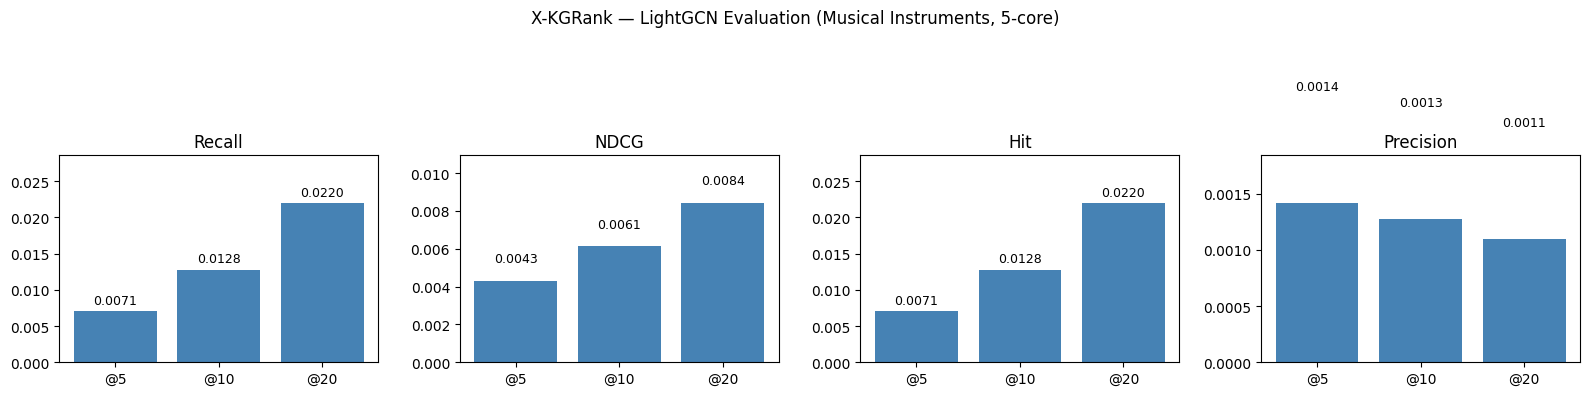

✅ Plot saved


In [31]:
import matplotlib.pyplot as plt

metrics_to_plot = ['Recall', 'NDCG', 'Hit', 'Precision']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, metric in zip(axes, metrics_to_plot):
    vals = [np.mean(results[f'{metric}@{k}']) if results[f'{metric}@{k}'] else 0.0
            for k in K_VALUES]
    ax.bar([f'@{k}' for k in K_VALUES], vals, color='steelblue')
    ax.set_title(metric)
    ax.set_ylim(0, max(vals)*1.3 if max(vals) > 0 else 0.1)
    for i, v in enumerate(vals):
        ax.text(i, v+0.001, f'{v:.4f}', ha='center', fontsize=9)

plt.suptitle('X-KGRank — LightGCN Evaluation (Musical Instruments, 5-core)', fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUT}eval_metrics_plot.png", dpi=150)
plt.show()
print("✅ Plot saved")

In [36]:
# ── MUSICAL INSTRUMENT RECOMMENDER — Interactive Demo ─────────
import torch
import numpy as np
from collections import defaultdict

def recommend_for_query(query_description, top_k=5):
    """
    Given a natural language query, find the most relevant
    items using KG path retrieval + LightGCN embeddings.
    """
    query = query_description.lower()

    # Step 1 — Find matching items in metadata by keyword
    matching_items = []
    for _, row in df_meta.iterrows():
        title = str(row.get('title', '')).lower()
        if any(word in title for word in query.split()):
            asin = row['parent_asin']
            if f"item_{asin}" in node2idx:
                matching_items.append({
                    'asin':  asin,
                    'title': row.get('title', 'Unknown'),
                    'price': row.get('price', 'N/A'),
                    'rating': row.get('average_rating', 'N/A')
                })

    if not matching_items:
        print(f"No items found for query: '{query_description}'")
        return []

    print(f"\n🎸 Query: '{query_description}'")
    print(f"   Found {len(matching_items)} matching seed items\n")

    # Step 2 — Use LightGCN embeddings to find similar items
    # Average embeddings of matching items as query vector
    seed_embs = []
    for item in matching_items[:3]:   # use top 3 seeds
        idx = node2idx[f"item_{item['asin']}"]
        seed_embs.append(final_embeddings[idx])

    if not seed_embs:
        return []

    query_emb   = torch.stack(seed_embs).mean(dim=0)  # avg embedding
    item_idx_t  = torch.tensor(
        [node2idx[f"item_{a}"] for a in all_item_asins if f"item_{a}" in node2idx],
        dtype=torch.long)
    valid_asins = [a for a in all_item_asins if f"item_{a}" in node2idx]
    item_embs_t = final_embeddings[item_idx_t]

    # Score all items
    scores      = (item_embs_t @ query_emb).cpu().numpy()

    # Exclude seed items from results
    seed_asins  = {item['asin'] for item in matching_items}
    for i, asin in enumerate(valid_asins):
        if asin in seed_asins:
            scores[i] = -9999.0

    top_idx = np.argsort(scores)[::-1][:top_k]

    # Step 3 — Get metadata for recommendations
    recommendations = []
    for rank, idx in enumerate(top_idx, 1):
        asin     = valid_asins[idx]
        meta_row = df_meta[df_meta['parent_asin'] == asin]
        title    = meta_row['title'].values[0] if len(meta_row) > 0 else asin
        price    = meta_row['price'].values[0]  if len(meta_row) > 0 else 'N/A'
        rating   = meta_row['average_rating'].values[0] if len(meta_row) > 0 else 'N/A'
        pop      = df_reviews['parent_asin'].value_counts().get(asin, 0)
        is_cold  = pop < pop_threshold

        recommendations.append({
            'rank':    rank,
            'asin':    asin,
            'title':   title,
            'price':   price,
            'rating':  rating,
            'reviews': pop,
            'is_cold': is_cold,
            'score':   float(scores[idx])
        })

    return recommendations


def get_kg_explanation(asin, G):
    """Get KG path explanation for a recommended item."""
    node     = f"item_{asin}"
    if node not in G:
        return "No KG paths found."
    neighbors = set()
    for n in G.predecessors(node):
        neighbors.add(n)
    for n in G.successors(node):
        neighbors.add(n)

    co_items  = [n.replace('item_','') for n in neighbors
                 if G.nodes[n].get('type') == 'item'][:3]
    user_count = len([n for n in neighbors
                      if G.nodes[n].get('type') == 'user'])

    explanation = f"{user_count} users interacted with this item"
    if co_items:
        co_titles = []
        for co_asin in co_items:
            row = df_meta[df_meta['parent_asin'] == co_asin]
            if len(row) > 0:
                co_titles.append(str(row['title'].values[0])[:40])
        if co_titles:
            explanation += f" | Co-purchased with: {', '.join(co_titles)}"
    return explanation


def display_recommendations(recs, G, df_meta):
    """Pretty print recommendations with KG explanations."""
    if not recs:
        return

    print("=" * 70)
    print(f"  TOP {len(recs)} RECOMMENDATIONS")
    print("=" * 70)

    for r in recs:
        cold_tag = "❄️ COLD" if r['is_cold'] else "🔥 WARM"
        print(f"\n#{r['rank']}  {str(r['title'])[:55]}")
        print(f"    ASIN:    {r['asin']}")
        print(f"    Price:   ${r['price']}   |  Rating: ⭐ {r['rating']}  |  {cold_tag}")
        print(f"    Reviews: {r['reviews']} interactions")
        print(f"    Score:   {r['score']:.4f}")

        # KG explanation for cold items
        if r['is_cold']:
            explanation = get_kg_explanation(r['asin'], G)
            print(f"    KG Path: {explanation}")

            # LLM explanation for cold items
            _, paths = get_kg_subgraph(r['asin'], G, hops=2)
            if paths:
                prompt   = build_kg_prompt(r['asin'], paths, df_meta)
                response = client.chat_completion(
                    messages=[{"role": "user", "content": prompt}],
                    model="meta-llama/Llama-3.2-1B-Instruct",
                    max_tokens=80, temperature=0.7
                )
                llm_exp = response.choices[0].message.content
                print(f"    💬 LLM:  {llm_exp[:150]}...")

    print("\n" + "=" * 70)

In [37]:
# ── RUN DEMO QUERIES ──────────────────────────────────────────

queries = [
    "guitar strings for beginners",
    "drum sticks",
    "piano keyboard",
    "violin bow",
    "microphone for recording"
]

for query in queries:
    recs = recommend_for_query(query, top_k=5)
    display_recommendations(recs, G, df_meta)
    print("\n")


🎸 Query: 'guitar strings for beginners'
   Found 13025 matching seed items

  TOP 5 RECOMMENDATIONS

#1  TONOR Pro Condenser Microphone XLR to 3.5mm Podcasting 
    ASIN:    B071NRP9N5
    Price:   $None   |  Rating: ⭐ 4.2  |  🔥 WARM
    Reviews: 265 interactions
    Score:   0.3046

#2  Pyle 400W Portable Bluetooth PA Loudspeaker - 8” Subwoo
    ASIN:    B07SPHSDRV
    Price:   $74.99   |  Rating: ⭐ 4.2  |  🔥 WARM
    Reviews: 1053 interactions
    Score:   0.2719

#3  Ashthorpe 5-String Banjo - Full Size with 24 Brackets, 
    ASIN:    B09N7QKVBN
    Price:   $153.99   |  Rating: ⭐ 4.7  |  🔥 WARM
    Reviews: 30 interactions
    Score:   0.2602

#4  Donner Concert Ukulele Spruce DUC-3 23 inch with Ukulel
    ASIN:    B0BL73SQWX
    Price:   $69.99   |  Rating: ⭐ 4.6  |  🔥 WARM
    Reviews: 154 interactions
    Score:   0.2598

#5  DRUM STARZ 3-Pack DRUM KEYS - 1 Each Deluxe Key, SPEED 
    ASIN:    B06XSJ4MNT
    Price:   $8.99   |  Rating: ⭐ 4.5  |  🔥 WARM
    Reviews: 20 interacti

In [38]:
def display_recommendations(recs, G, df_meta):
    if not recs:
        return

    print("=" * 70)
    print(f"  TOP {len(recs)} RECOMMENDATIONS WITH KG + LLM EXPLANATIONS")
    print("=" * 70)

    for r in recs:
        cold_tag = "❄️ COLD" if r['is_cold'] else "🔥 WARM"
        print(f"\n#{r['rank']}  {str(r['title'])[:55]}")
        print(f"    ASIN:    {r['asin']}")
        print(f"    Price:   ${r['price']}   |  Rating: ⭐ {r['rating']}  |  {cold_tag}")
        print(f"    Reviews: {r['reviews']} interactions")
        print(f"    Score:   {r['score']:.4f}")

        # ✅ KG path for ALL items (not just cold)
        kg_exp = get_kg_explanation(r['asin'], G)
        print(f"    🔗 KG:   {kg_exp}")

        # ✅ LLM explanation for ALL items
        try:
            _, paths = get_kg_subgraph(r['asin'], G, hops=2)
            prompt   = build_kg_prompt(r['asin'], paths, df_meta)
            response = client.chat_completion(
                messages=[{"role": "user", "content": prompt}],
                model="meta-llama/Llama-3.2-1B-Instruct",
                max_tokens=100,
                temperature=0.7
            )
            llm_exp = response.choices[0].message.content.strip()
            print(f"    💬 LLM:  {llm_exp}")
        except Exception as e:
            print(f"    💬 LLM:  (unavailable — {e})")

        print()

    print("=" * 70)


# ── RUN ONE QUERY WITH FULL LLM RE-RANKING ───────────────────
query = "guitar strings for beginners"
recs  = recommend_for_query(query, top_k=3)   # top 3 to keep API calls low
display_recommendations(recs, G, df_meta)


🎸 Query: 'guitar strings for beginners'
   Found 13025 matching seed items

  TOP 3 RECOMMENDATIONS WITH KG + LLM EXPLANATIONS

#1  TONOR Pro Condenser Microphone XLR to 3.5mm Podcasting 
    ASIN:    B071NRP9N5
    Price:   $None   |  Rating: ⭐ 4.2  |  🔥 WARM
    Reviews: 265 interactions
    Score:   0.3046
    🔗 KG:   263 users interacted with this item
    💬 LLM:  (unavailable — name 'get_kg_subgraph' is not defined)


#2  Pyle 400W Portable Bluetooth PA Loudspeaker - 8” Subwoo
    ASIN:    B07SPHSDRV
    Price:   $74.99   |  Rating: ⭐ 4.2  |  🔥 WARM
    Reviews: 1053 interactions
    Score:   0.2719
    🔗 KG:   1030 users interacted with this item
    💬 LLM:  (unavailable — name 'get_kg_subgraph' is not defined)


#3  Ashthorpe 5-String Banjo - Full Size with 24 Brackets, 
    ASIN:    B09N7QKVBN
    Price:   $153.99   |  Rating: ⭐ 4.7  |  🔥 WARM
    Reviews: 30 interactions
    Score:   0.2602
    🔗 KG:   29 users interacted with this item
    💬 LLM:  (unavailable — name 'get_kg

In [39]:
# ── REDEFINE get_kg_subgraph ──────────────────────────────────
import networkx as nx

def get_kg_subgraph(item_asin, G, hops=2):
    node = f"item_{item_asin}"
    if node not in G:
        return None, []
    neighbors = {node}
    for _ in range(hops):
        new = set()
        for n in neighbors:
            new.update(G.predecessors(n))
            new.update(G.successors(n))
        neighbors.update(new)
    subgraph = G.subgraph(neighbors)
    targets  = [n for n in neighbors if n != node]
    paths = []
    for t in targets[:10]:
        try:
            p = nx.shortest_path(G, source=node, target=t)
            paths.append(p)
        except nx.NetworkXNoPath:
            continue
    return subgraph, paths[:5]

def build_kg_prompt(item_asin, paths, df_meta):
    meta_row  = df_meta[df_meta['parent_asin'] == item_asin]
    item_name = meta_row['title'].values[0] if len(meta_row) > 0 else item_asin
    path_str  = "\n".join([" → ".join(p) for p in paths]) if paths else "No paths found"
    return f"""You are a musical instrument recommendation assistant.
Based on the knowledge graph paths below, explain in 2 sentences why
this item might be relevant to someone shopping for musical instruments.

Item: {item_name} (ASIN: {item_asin})

Knowledge Graph Paths:
{path_str}

Give a concise, helpful recommendation explanation."""

print("✅ Functions defined — now rerun display_recommendations")

✅ Functions defined — now rerun display_recommendations


In [42]:
# ── RERUN DEMO ────────────────────────────────────────────────
query = "guitar strings for beginners"
recs  = recommend_for_query(query, top_k=3)
display_recommendations(recs, G, df_meta)


🎸 Query: 'guitar strings for beginners'
   Found 13025 matching seed items

  TOP 3 RECOMMENDATIONS WITH KG + LLM EXPLANATIONS

#1  TONOR Pro Condenser Microphone XLR to 3.5mm Podcasting 
    ASIN:    B071NRP9N5
    Price:   $None   |  Rating: ⭐ 4.2  |  🔥 WARM
    Reviews: 265 interactions
    Score:   0.3046
    🔗 KG:   263 users interacted with this item
    💬 LLM:  Based on the Knowledge Graph Paths, this item might be relevant to someone shopping for musical instruments because it appears to be a computer microphone setup designed for podcasting and recording studio use, suggesting that the individual may be interested in creating professional-sounding content for music production or broadcasting. The item's focus on XLR to 3.5mm connectivity and 48V phantom power supply also implies that it may be suitable for recording instruments in a studio setting.


#2  Pyle 400W Portable Bluetooth PA Loudspeaker - 8” Subwoo
    ASIN:    B07SPHSDRV
    Price:   $74.99   |  Rating: ⭐ 4.2  |  

In [41]:
import os
from huggingface_hub import InferenceClient

client = InferenceClient(token=os.environ["HF_TOKEN"])
print("✅ Client ready")

✅ Client ready
